<a href="https://colab.research.google.com/github/BenGreenleaf/Helios/blob/main/helios_orifice_sizing_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# H2 injector orifice sizing — 20 bar feed

In [1]:
import numpy as np
import matplotlib.pyplot as plt


**Gas properties + ideal-gas check.**

In [2]:
gamma = 1.405
M     = 2.016e-3
Ru    = 8.314
R     = Ru / M
T0    = 293.0

Tc, Pc_bar = 33.2, 13.0
Tr, Pr = T0/Tc, 20.0/Pc_bar

print(f"R = {R:.1f} J/kg/K")
print(f"Tr = {Tr:.1f}, Pr = {Pr:.1f} -> Tr >> 1, ideal-gas model adequate")


R = 4124.0 J/kg/K
Tr = 8.8, Pr = 1.5 -> Tr >> 1, ideal-gas model adequate


**Pressure basis.** Chamber P3 treated as absolute (462 K compression convention). "20 bar" feed carried as both gauge and absolute since it isn't specified.

In [3]:
atm = 1.01325
P3_abs_bar = 3.5
P_feed_abs_if_gauge    = 20.0 + atm
P_feed_abs_if_absolute = 20.0
print(f"P3 = {P3_abs_bar} bar abs")
print(f"P_feed = {P_feed_abs_if_gauge:.2f} bar abs (if gauge) / {P_feed_abs_if_absolute:.2f} bar abs (if absolute)")


P3 = 3.5 bar abs
P_feed = 21.01 bar abs (if gauge) / 20.00 bar abs (if absolute)


**Governing equations.**

$$\left(\frac{P_0}{P^*}\right)_{crit} = \left(\frac{\gamma+1}{2}\right)^{\gamma/(\gamma-1)}, \quad
\Gamma = \sqrt{\gamma\left(\frac{2}{\gamma+1}\right)^{(\gamma+1)/(\gamma-1)}}, \quad
\dot{m} = C_d A^* \frac{P_0\,\Gamma}{\sqrt{R T_0}}$$


In [4]:
crit_ratio = ((gamma + 1) / 2) ** (gamma / (gamma - 1))
GAMMA = np.sqrt(gamma * (2 / (gamma + 1)) ** ((gamma + 1) / (gamma - 1)))
Cd = 0.55

def choked_mdot_gs(d_mm, P0_bar_abs, T0=T0, Cd=Cd):
    A = np.pi * (d_mm / 2e3) ** 2
    return Cd * A * (P0_bar_abs * 1e5) * GAMMA / np.sqrt(R * T0) * 1e3

def required_diam_mm(mdot_gs, P0_bar_abs, T0=T0, Cd=Cd):
    A = (mdot_gs / 1e3) * np.sqrt(R * T0) / (Cd * (P0_bar_abs * 1e5) * GAMMA)
    return np.sqrt(4 * A / np.pi) * 1e3

def required_P0_bar_abs(mdot_gs, d_mm, T0=T0, Cd=Cd):
    A = np.pi * (d_mm / 2e3) ** 2
    return (mdot_gs / 1e3) * np.sqrt(R * T0) / (Cd * A * GAMMA) / 1e5

print(f"Critical ratio = {crit_ratio:.3f}, Gamma = {GAMMA:.3f}")


Critical ratio = 1.896, Gamma = 0.686


**Choke threshold.** Result: minimum injector pressure to stay choked against the 3.5 bar chamber.

In [5]:
P_inj_min_abs_bar = crit_ratio * P3_abs_bar
print(f"P_inj,min = {P_inj_min_abs_bar:.3f} bar abs ({P_inj_min_abs_bar-atm:.3f} bar gauge)")


P_inj,min = 6.636 bar abs (5.623 bar gauge)


**Orifice sizing.** Diameter needed for 6 g/s at max available pressure, swept over gauge/absolute and a 2-10% loss allowance. Result: 3.4 mm covers the range with margin.

In [6]:
print(f"{'Feed interp.':<22}{'Loss':<10}{'P_inj,max (bar abs)':<22}{'d* for 6 g/s (mm)'}")
results = []
for label, Pfeed in [("gauge", P_feed_abs_if_gauge), ("absolute", P_feed_abs_if_absolute)]:
    for loss_frac in [0.02, 0.05, 0.10]:
        P_inj_max = Pfeed * (1 - loss_frac)
        d = required_diam_mm(6.0, P_inj_max)
        results.append(d)
        print(f"{label:<22}{f'{loss_frac*100:.0f}%':<10}{P_inj_max:<22.2f}{d:.3f}")

d_nom = 3.4
print(f"\nSelected: d* = {d_nom} mm  (covers {min(results):.2f}-{max(results):.2f} mm range)")


Feed interp.          Loss      P_inj,max (bar abs)   d* for 6 g/s (mm)
gauge                 2%        20.59                 3.289
gauge                 5%        19.96                 3.340
gauge                 10%       18.91                 3.432
absolute              2%        19.60                 3.371
absolute              5%        19.00                 3.424
absolute              10%       18.00                 3.517

Selected: d* = 3.4 mm  (covers 3.29-3.52 mm range)


**Throttling curve, 3-6 g/s.** Required injector pressure at the fixed 3.4 mm orifice, checked against the choke threshold. Result: choked throughout, worst-case margin at 3 g/s.

In [7]:
mdot_points = [3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
print(f"{'mdot (g/s)':<12}{'P_inj req (bar abs)':<22}{'Margin':<10}{'Status'}")
throttling_curve = []
for m in mdot_points:
    P0 = required_P0_bar_abs(m, d_nom)
    margin = P0 / P_inj_min_abs_bar
    throttling_curve.append((m, P0, margin))
    print(f"{m:<12}{P0:<22.2f}{margin:<10.2f}{'OK' if margin>1 else 'FAIL'}")

worst_margin = min(t[2] for t in throttling_curve)
print(f"\nWorst-case margin (3 g/s): x{worst_margin:.2f}")


mdot (g/s)  P_inj req (bar abs)   Margin    Status
3.0         9.63                  1.45      OK
3.5         11.24                 1.69      OK
4.0         12.84                 1.94      OK
4.5         14.45                 2.18      OK
5.0         16.05                 2.42      OK
5.5         17.66                 2.66      OK
6.0         19.27                 2.90      OK

Worst-case margin (3 g/s): x1.45


**Plot — mass flow vs orifice diameter**, at the 3 g/s and 6 g/s injector-pressure conditions.

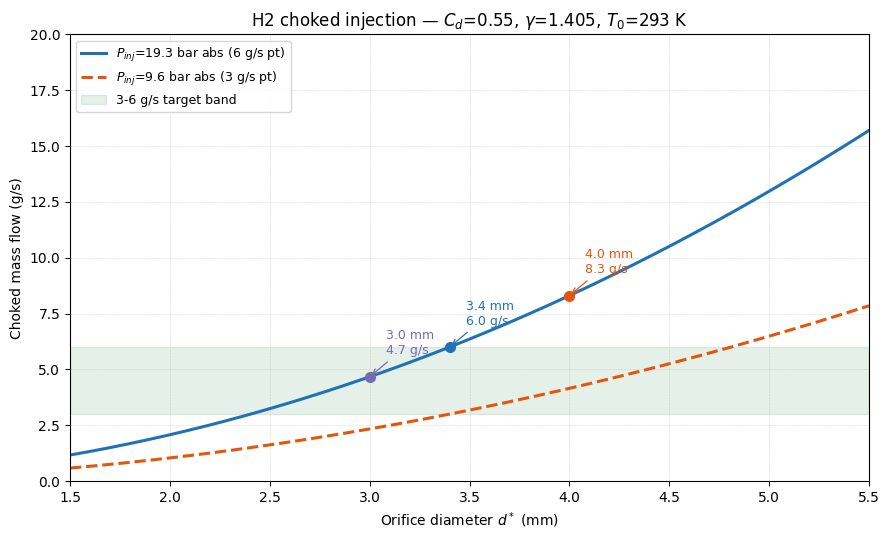

In [8]:
d_arr = np.linspace(1.5, 5.5, 500)
P_ref_high = required_P0_bar_abs(6.0, d_nom)
P_ref_low  = required_P0_bar_abs(3.0, d_nom)
m_high = choked_mdot_gs(d_arr, P_ref_high)
m_low  = choked_mdot_gs(d_arr, P_ref_low)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(d_arr, m_high, color='#2171b5', linewidth=2.2, label=f'$P_{{inj}}$={P_ref_high:.1f} bar abs (6 g/s pt)')
ax.plot(d_arr, m_low, color='#e6550d', linewidth=2.2, linestyle='--', label=f'$P_{{inj}}$={P_ref_low:.1f} bar abs (3 g/s pt)')
ax.axhspan(3, 6, color='#238b45', alpha=0.12, label='3-6 g/s target band')
for d, col in [(3.0, '#756bb1'), (3.4, '#2171b5'), (4.0, '#e6550d')]:
    m_at = choked_mdot_gs(d, P_ref_high)
    ax.plot(d, m_at, 'o', color=col, markersize=7, zorder=5)
    ax.annotate(f'{d} mm\n{m_at:.1f} g/s', xy=(d, m_at), xytext=(d+0.08, m_at+1.0), fontsize=9, color=col,
                arrowprops=dict(arrowstyle='->', color=col, lw=0.9))
ax.set_xlabel('Orifice diameter $d^*$ (mm)'); ax.set_ylabel('Choked mass flow (g/s)')
ax.set_title(f'H2 choked injection — $C_d$={Cd}, $\\gamma$={gamma}, $T_0$={T0:.0f} K')
ax.set_xlim(1.5, 5.5); ax.set_ylim(0, 20)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5); ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.savefig('h2_orifice_sizing.png', dpi=150, bbox_inches='tight'); plt.show()


**Plot — needle-valve throttling curve.**

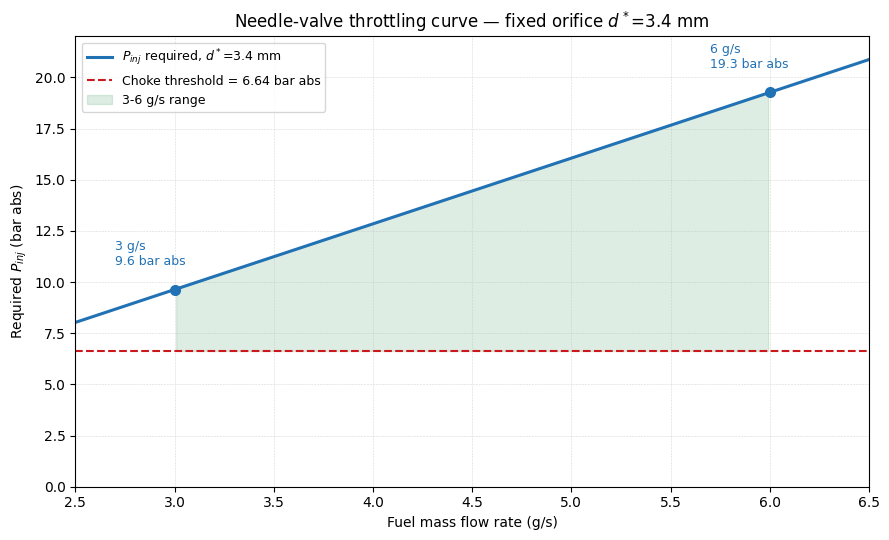

In [9]:
m_sweep = np.linspace(2.5, 6.5, 300)
P_sweep = required_P0_bar_abs(m_sweep, d_nom)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(m_sweep, P_sweep, color='#2171b5', linewidth=2.2, label=f'$P_{{inj}}$ required, $d^*$={d_nom} mm')
ax.axhline(P_inj_min_abs_bar, color='#cb181d', linewidth=1.5, linestyle='--', label=f'Choke threshold = {P_inj_min_abs_bar:.2f} bar abs')
in_range = (m_sweep >= 3.0) & (m_sweep <= 6.0)
ax.fill_between(m_sweep, P_sweep, P_inj_min_abs_bar, where=in_range, color='#238b45', alpha=0.15, label='3-6 g/s range')
for m in [3.0, 6.0]:
    P0 = required_P0_bar_abs(m, d_nom)
    ax.plot(m, P0, 'o', color='#2171b5', markersize=7, zorder=5)
    ax.annotate(f'{m:.0f} g/s\n{P0:.1f} bar abs', xy=(m, P0), xytext=(m-0.3, P0+1.2), fontsize=9, color='#2171b5')
ax.set_xlabel('Fuel mass flow rate (g/s)'); ax.set_ylabel('Required $P_{inj}$ (bar abs)')
ax.set_title(f'Needle-valve throttling curve — fixed orifice $d^*$={d_nom} mm')
ax.set_xlim(2.5, 6.5); ax.set_ylim(0, 22)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5); ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.savefig('h2_throttling_curve.png', dpi=150, bbox_inches='tight'); plt.show()


**Plot — choking margin vs injector inlet pressure.**

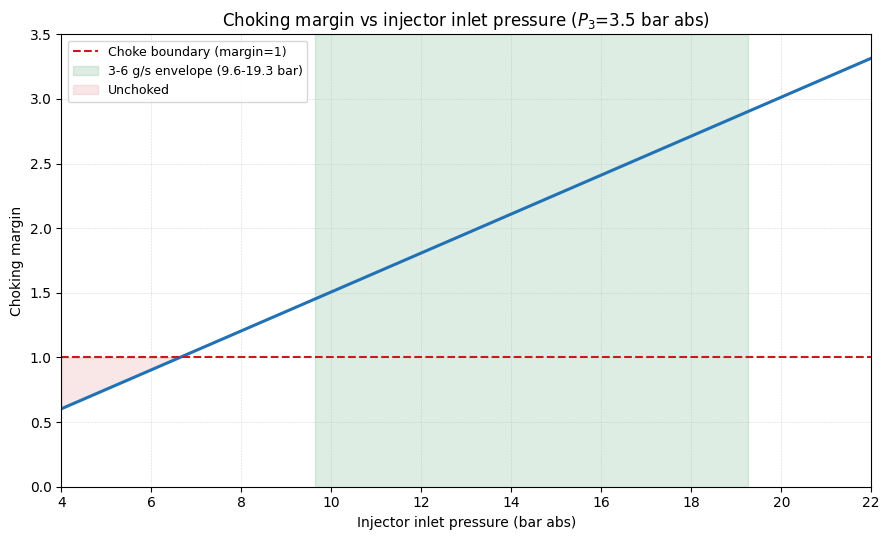

In [10]:
P_inj_sweep = np.linspace(4, 22, 400)
margin_sweep = P_inj_sweep / P_inj_min_abs_bar

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(P_inj_sweep, margin_sweep, color='#2171b5', linewidth=2.2)
ax.axhline(1.0, color='#cb181d', linewidth=1.5, linestyle='--', label='Choke boundary (margin=1)')
P_op_low, P_op_high = required_P0_bar_abs(3.0, d_nom), required_P0_bar_abs(6.0, d_nom)
ax.axvspan(P_op_low, P_op_high, color='#238b45', alpha=0.15, label=f'3-6 g/s envelope ({P_op_low:.1f}-{P_op_high:.1f} bar)')
ax.fill_between(P_inj_sweep, margin_sweep, 1.0, where=(margin_sweep < 1.0), color='#cb181d', alpha=0.10, label='Unchoked')
ax.set_xlabel('Injector inlet pressure (bar abs)'); ax.set_ylabel('Choking margin')
ax.set_title('Choking margin vs injector inlet pressure ($P_3$=3.5 bar abs)')
ax.set_xlim(4, 22); ax.set_ylim(0, 3.5)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5); ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.savefig('h2_choking_margin.png', dpi=150, bbox_inches='tight'); plt.show()


**Sensitivity — Cd and T0**, at the 6 g/s design condition.

In [11]:
print("Cd sensitivity:")
for cd in [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    print(f"  Cd={cd:.2f}  mdot={choked_mdot_gs(d_nom, P_ref_high, Cd=cd):.2f} g/s")

print("\nT0 sensitivity:")
for t in [270, 280, 290, 293, 300, 310]:
    print(f"  T0={t} K  mdot={choked_mdot_gs(d_nom, P_ref_high, T0=t):.2f} g/s")


Cd sensitivity:
  Cd=0.45  mdot=4.91 g/s
  Cd=0.50  mdot=5.45 g/s
  Cd=0.55  mdot=6.00 g/s
  Cd=0.60  mdot=6.55 g/s
  Cd=0.65  mdot=7.09 g/s
  Cd=0.70  mdot=7.64 g/s

T0 sensitivity:
  T0=270 K  mdot=6.25 g/s
  T0=280 K  mdot=6.14 g/s
  T0=290 K  mdot=6.03 g/s
  T0=293 K  mdot=6.00 g/s
  T0=300 K  mdot=5.93 g/s
  T0=310 K  mdot=5.83 g/s


**Sensitivity — injector pressure near 20 bar.** Result: even a large feed-pressure shortfall still clears the choke threshold.

In [12]:
for P_inj in [22, 21, 20, 19, 18, 17, 16, P_inj_min_abs_bar]:
    m = choked_mdot_gs(d_nom, P_inj)
    print(f"P_inj={P_inj:5.2f} bar abs  mdot={m:5.2f} g/s  margin=x{P_inj/P_inj_min_abs_bar:.2f}")


P_inj=22.00 bar abs  mdot= 6.85 g/s  margin=x3.32
P_inj=21.00 bar abs  mdot= 6.54 g/s  margin=x3.16
P_inj=20.00 bar abs  mdot= 6.23 g/s  margin=x3.01
P_inj=19.00 bar abs  mdot= 5.92 g/s  margin=x2.86
P_inj=18.00 bar abs  mdot= 5.61 g/s  margin=x2.71
P_inj=17.00 bar abs  mdot= 5.29 g/s  margin=x2.56
P_inj=16.00 bar abs  mdot= 4.98 g/s  margin=x2.41
P_inj= 6.64 bar abs  mdot= 2.07 g/s  margin=x1.00


**Summary.**

In [13]:
print(f"P_inj,min (choke threshold): {P_inj_min_abs_bar:.2f} bar abs")
print(f"Orifice diameter: {d_nom} mm (modular set 3.0/3.4/4.0 mm)")
print(f"P_inj required @ 3 g/s: {required_P0_bar_abs(3.0, d_nom):.2f} bar abs")
print(f"P_inj required @ 6 g/s: {required_P0_bar_abs(6.0, d_nom):.2f} bar abs")
print(f"Minimum choke margin across 3-6 g/s: x{worst_margin:.2f}")


P_inj,min (choke threshold): 6.64 bar abs
Orifice diameter: 3.4 mm (modular set 3.0/3.4/4.0 mm)
P_inj required @ 3 g/s: 9.63 bar abs
P_inj required @ 6 g/s: 19.27 bar abs
Minimum choke margin across 3-6 g/s: x1.45
